# Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# pre_processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# sklearn - models
from sklearn.ensemble import RandomForestClassifier

# sklearn - metrics
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score,recall_score,precision_score

## Read data

In [2]:
df=pd.read_csv('crop_data1.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# EDA

In [3]:
# to know shape data
df.shape

(2200, 8)

In [4]:
# to  know type data
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
# to see if data have null or no
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
# count unique values in target column
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

----------------------

# VIZ

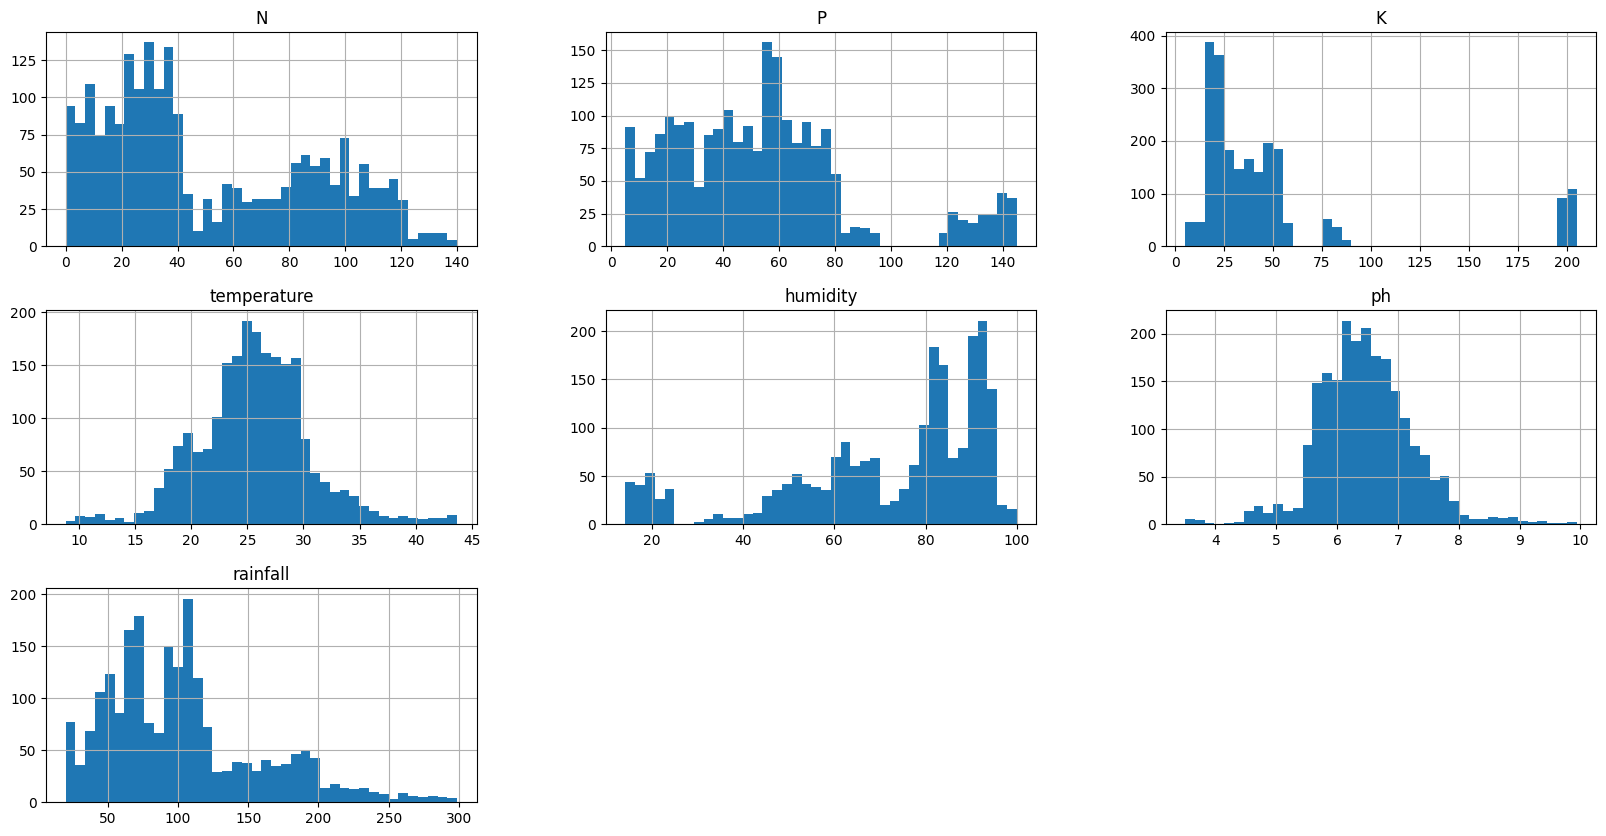

In [9]:
# check if data has outlier or no
df.hist(bins=40,figsize=(20,10))
plt.show()

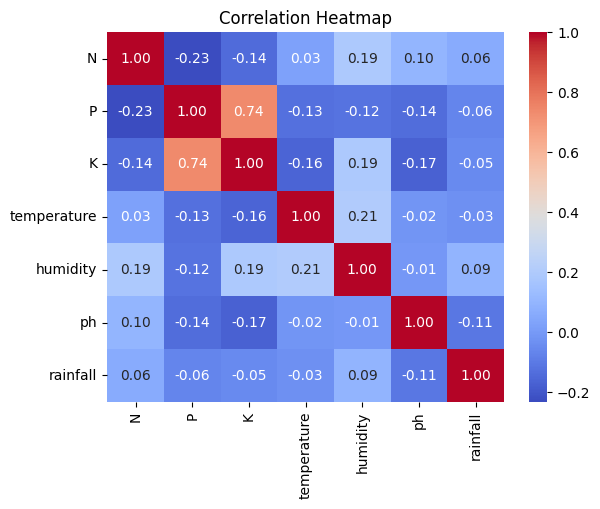

In [11]:
# Correlation between Features
correlation_matrix = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph','rainfall',]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

-----------

In [12]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

* `Splitting Dataset to train & test`

In [13]:
# Split X & y
X = df.drop(columns=['label'], axis=1)
y = df['label']

In [14]:
# Split to train & test folds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=45, shuffle=True, stratify=y)

## Check shapes
print('X_train.shape \t', X_train.shape)
print('y_train.shape \t', y_train.shape)
print('***'*10)
print('X_test.shape \t', X_test.shape)
print('y_test.shape \t', y_test.shape)

X_train.shape 	 (1760, 7)
y_train.shape 	 (1760,)
******************************
X_test.shape 	 (440, 7)
y_test.shape 	 (440,)


------------

# pre_processing 

In [15]:
num_cols=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

In [16]:
# Pipeline

# Numerical: num_cols -->  StandardScaler

# For Numerical
num_pipeline = Pipeline(steps=[
                    ('scaler', StandardScaler())
                ])




# Combine all secondary pipelines into one total pipeline
all_pipeline = ColumnTransformer(transformers=[
                    ('numerical', num_pipeline, num_cols),
                    
                ])


# Apply
X_train_final = all_pipeline.fit_transform(X_train)
X_test_final = all_pipeline.transform(X_test)

* `Save Pipline`

In [17]:
joblib.dump(all_pipeline,'pipline.pkl')

['pipline.pkl']

In [18]:
# covert objcet to numbers
le=LabelEncoder()
y_train_final=le.fit_transform(y_train)
y_test_final=le.transform(y_test)

In [19]:
# Save LabelEncoder
joblib.dump(le,'Label-Encoder.pkl')

['Label-Encoder.pkl']

In [20]:
# If you want to see the processed array
pd.DataFrame(X_train_final)

,0,1,2,3,4,5,6
0,0.936655,-0.463905,-0.140962,-0.791201,0.507299,-0.283022,3.158905
1,-1.023494,-1.462815,-0.793423,-0.344607,0.836021,1.296353,0.009743
2,-1.159615,-0.917955,-0.200277,-1.241691,0.704489,0.691617,0.038064
3,1.862280,1.110135,-0.002561,0.604009,0.363715,-0.621417,0.271094
4,-0.288438,-0.252015,-0.556165,0.743847,-0.620011,0.528079,-1.185882
...,...,...,...,...,...,...,...
1755,-0.615130,0.686355,0.669671,-0.992419,-2.571550,0.239340,-0.357874
1756,1.018328,-0.463905,-0.655022,-0.102422,-0.250455,-0.017487,-0.745612
1757,1.372243,-0.675795,-0.437535,0.218111,-0.080188,0.505834,1.011338
1758,-1.186840,2.744716,2.903856,-0.519896,0.992162,-0.788884,0.022944


--------------------

# Building Model

* `Using Random Forest`

In [21]:
# 2. Using class_weight
forest_clf = RandomForestClassifier(criterion='gini', n_estimators=10, 
                                    max_depth=4, random_state=45)
forest_clf.fit(X_train_final, y_train_final)

# Predict and evaluate
y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_foerst = forest_clf.predict(X_test_final)

# Using f1_score
f1_train_forest = f1_score(y_train_final, y_pred_train_forest,average='weighted')
f1_test_forest = f1_score(y_test_final, y_pred_test_foerst,average='weighted')

print(f'The f1_score using RF model for Training Dataset  is {f1_train_forest*100:.3f}')
print(f'The f1_score using RF model for Testing Dataset is {f1_test_forest*100:.3f}')

The f1_score using RF model for Training Dataset  is 96.519
The f1_score using RF model for Testing Dataset is 95.818


In [22]:
# another Metrics
precision = precision_score(y_test_final, y_pred_test_foerst,average='weighted')
recall = recall_score(y_test_final, y_pred_test_foerst,average='weighted')
accuracy = accuracy_score(y_test_final, y_pred_test_foerst)


print(f"🎯 Accuracy using RF : {accuracy*100:.2f}%")
print(f"✅ Precision using RF : {precision*100:.2f}%")
print(f"🔁 Recall using RF   : {recall*100:.2f}%")


metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Value': [accuracy, precision, recall]
})
display(metrics_df)

🎯 Accuracy using RF : 95.91%
✅ Precision using RF : 96.29%
🔁 Recall using RF   : 95.91%


,Metric,Value
0,Accuracy,0.959091
1,Precision,0.962896
2,Recall,0.959091


## Save Model

In [23]:
joblib.dump(forest_clf,'Rondom forest.pkl')

['Rondom forest.pkl']

------------------

# inference 

In [24]:
# 1️⃣ Load saved pipeline and label encoder
loaded_pipeline = joblib.load('pipline.pkl')
loaded_label_encoder = joblib.load('Label-Encoder.pkl')

# 2️⃣ Choose a sample from the test set
sample_index = 1   # 👈 غيّر الرقم عشان تختار صف تاني
sample_X = X_test.iloc[[sample_index]]   # DataFrame with 1 row
sample_y_true = y_test.iloc[sample_index]

print("🔹 Input sample:")
display(sample_X)

# 3️⃣ Transform and predict
sample_X_transformed = loaded_pipeline.transform(sample_X)
sample_pred_encoded = forest_clf.predict(sample_X_transformed)[0]

# 4️⃣ Decode label back to original name
sample_pred_label = loaded_label_encoder.inverse_transform([sample_pred_encoded])[0]

# 5️⃣ Show result
print(f"\n✅ True label: {sample_y_true}")
print(f"🤖 Model prediction: {sample_pred_label}")


🔹 Input sample:


,N,P,K,temperature,humidity,ph,rainfall
762,28,65,23,28.386865,61.888711,7.405176,74.244591



✅ True label: blackgram
🤖 Model prediction: blackgram
